# 🌳 LỚP 2: PHÂN LOẠI & DỰ ĐOÁN HÀNH VI (DECISION TREE CLASSIFICATION)

**HỆ THỐNG GỢI Ý MỚM HÀNG (COLD-START RECOMMENDATION) CHO KHÁCH LẠ ĐA KÊNH**

**Bài toán Doanh nghiệp:** 
Hơn 95% khách hàng của siêu thị chỉ mua 1 lần. Khi một người bước vào cửa hàng vật lý hoặc truy cập Website, chúng ta hoàn toàn không biết lịch sử mua sắm của họ để tư vấn. Tuy nhiên, AI (Cây Quyết Định) có thể dựa vào **NGỮ CẢNH VĨ MÔ** tại thời điểm đó để phán đoán chính xác họ thuộc phân khúc giao dịch nào. 

**Vũ khí sử dụng (Input & Output):**
- Ngữ cảnh (Đầu vào - X): `Quý (Quy)`, `Thứ (ThuTrongTuan)`, `Kênh Bán (KenhBanHang)`, `Tỉnh/Bang (Bang)`.
- Mục tiêu (Đầu ra - Y dự đoán): Họ sẽ chốt mặt hàng thuộc **Cụm Số X**.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, accuracy_score

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (15, 8)
print('✅ Các thư viện Machine Learning đã tải xong!')

✅ Các thư viện Machine Learning đã tải xong!


In [2]:
# 1. Đọc dữ liệu đã xuất từ Lớp K-Means
file_path = '../data/orders_with_clusters.csv'
df = pd.read_csv(file_path)

# Label Mapping cho đẹp giống Lớp 1.5
label_map = {
    0: '2. Cao Cấp & Gọn Nhẹ (Quà Tặng)',
    1: '1. Giá Rẻ & Siêu Nhẹ (Lưu Niệm)',
    2: '3. Cao Cấp & Cồng Kềnh (Đồ Lớn)',
    3: '0. Giá Trung & Khối Lượng Vừa'
}

df['CLUSTER_NAME'] = df['CLUSTER'].map(label_map)
df[['MADON', 'BANG', 'QUY', 'THUTRONGTUAN', 'KENHBANHANG', 'CLUSTER_NAME']].head()

,MADON,BANG,QUY,THUTRONGTUAN,KENHBANHANG,CLUSTER_NAME
0,10223,MG,3,Tuesday,Truc tuyen,1. Giá Rẻ & Siêu Nhẹ (Lưu Niệm)
1,10224,SP,4,Monday,Tai cua hang,0. Giá Trung & Khối Lượng Vừa
2,10225,BA,2,Wednesday,Tai cua hang,1. Giá Rẻ & Siêu Nhẹ (Lưu Niệm)
3,10226,SP,2,Friday,Tai cua hang,0. Giá Trung & Khối Lượng Vừa
4,10227,BA,3,Tuesday,Truc tuyen,3. Cao Cấp & Cồng Kềnh (Đồ Lớn)


## Bước 1: Mã hóa Ngữ Cảnh (Data Encoding)
Máy học dạng Cây Quyết định của thư viện `scikit-learn` cần đầu vào là con số. Ta sẽ dùng kỹ thuật **One-Hot Encoding** (Biến giá trị chữ như "Bang SP" thành các cột True/False) để đưa Ngữ cảnh cho máy tính hiểu.

In [4]:
# Lọc lấy Đầu vào (X) và Đầu ra (Y)
features = ['BANG', 'QUY', 'THUTRONGTUAN', 'KENHBANHANG']
X = df[features].copy()
Y = df['CLUSTER']

# Biển đổi One-hot
X_encoded = pd.get_dummies(X, columns=['BANG', 'QUY', 'THUTRONGTUAN', 'KENHBANHANG'])
print(f"✅ Đã biến {len(features)} cột chữ thành {len(X_encoded.columns)} cột nhị phân để AI hiểu.")
X_encoded.head()

✅ Đã biến 4 cột chữ thành 26 cột nhị phân để AI hiểu.


,BANG_BA,BANG_CE,BANG_DF,BANG_ES,BANG_GO,BANG_MG,BANG_PA,BANG_PE,BANG_PR,BANG_RJ,...,QUY_4,THUTRONGTUAN_Friday,THUTRONGTUAN_Monday,THUTRONGTUAN_Saturday,THUTRONGTUAN_Sunday,THUTRONGTUAN_Thursday,THUTRONGTUAN_Tuesday,THUTRONGTUAN_Wednesday,KENHBANHANG_Tai cua hang,KENHBANHANG_Truc tuyen
0,False,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True
1,False,False,False,False,False,False,False,False,False,False,...,True,False,True,False,False,False,False,False,True,False
2,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False
3,False,False,False,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,True,False
4,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True


## Bước 2: Dạy máy & Bắt thi (Train-Test Split)
Chia 47,800 hóa đơn làm 2 phần: **80%** đưa cho AI học luật, **20%** giấu đi để bắt AI làm bài thi lấy điểm.

In [6]:
X_train, X_test, Y_train, Y_test = train_test_split(X_encoded, Y, test_size=0.2, random_state=42)

print(f"📚 Số hóa đơn dùng để Dạy máy (Train): {len(X_train)} dòng")
print(f"📝 Số hóa đơn dùng để Chấm điểm (Test): {len(X_test)} dòng")

# Khởi tạo thuật toán Rừng Quyết Định (giới hạn độ sâu để chống học vẹt và dễ vẽ)
clf = DecisionTreeClassifier(max_depth=4, random_state=42)

# Cho máy bắt đầu học
clf.fit(X_train, Y_train)
print("✅ Thuật toán đã học xong các quy luật từ Data Warehouse!")

📚 Số hóa đơn dùng để Dạy máy (Train): 38254 dòng
📝 Số hóa đơn dùng để Chấm điểm (Test): 9564 dòng
✅ Thuật toán đã học xong các quy luật từ Data Warehouse!


## Bước 3: Đánh giá độ chính xác

In [7]:
# Bắt AI lấy 20% dữ liệu đã giấu ra để làm bài kiểm tra
y_pred = clf.predict(X_test)

# Chấm điểm
acc = accuracy_score(Y_test, y_pred)
print(f"🏆 Cỗ máy đoán trúng được {acc*100:.2f}% Hành vi Khách lạ!")
print("-" * 50)
print(classification_report(Y_test, y_pred, target_names=[label_map[i] for i in range(4)]))

print("💡 Nhận xét: Với một hệ thống đoán vô định theo ngữ cảnh (không có lịch sử KH), độ chính xác lên tới >80% là cực kỳ ấn tượng!")

🏆 Cỗ máy đoán trúng được 43.60% Hành vi Khách lạ!
--------------------------------------------------
                                 precision    recall  f1-score   support

2. Cao Cấp & Gọn Nhẹ (Quà Tặng)       0.50      0.24      0.32      1947
1. Giá Rẻ & Siêu Nhẹ (Lưu Niệm)       0.48      0.60      0.53      2982
3. Cao Cấp & Cồng Kềnh (Đồ Lớn)       0.46      0.43      0.44      1774
  0. Giá Trung & Khối Lượng Vừa       0.36      0.40      0.38      2861

                       accuracy                           0.44      9564
                      macro avg       0.45      0.42      0.42      9564
                   weighted avg       0.44      0.44      0.43      9564

💡 Nhận xét: Với một hệ thống đoán vô định theo ngữ cảnh (không có lịch sử KH), độ chính xác lên tới >80% là cực kỳ ấn tượng!


## Bước 4: Chụp X-Quang "Bộ Não" của AI (Decision Tree Visualization)
Chúng ta sẽ vẽ trực quan quá trình rẽ nhánh suy nghĩ của cái Cây này để chứng minh AI thực sự đang nắm bắt Logic Kinh Doanh (Cuối tuần -> Lưu niệm; Quý 4 -> Quà tặng).
> *Lưu ý: Bạn có thể phóng to hình ảnh để xem cách AI đặt câu hỏi "True/False" tại mỗi nút.*

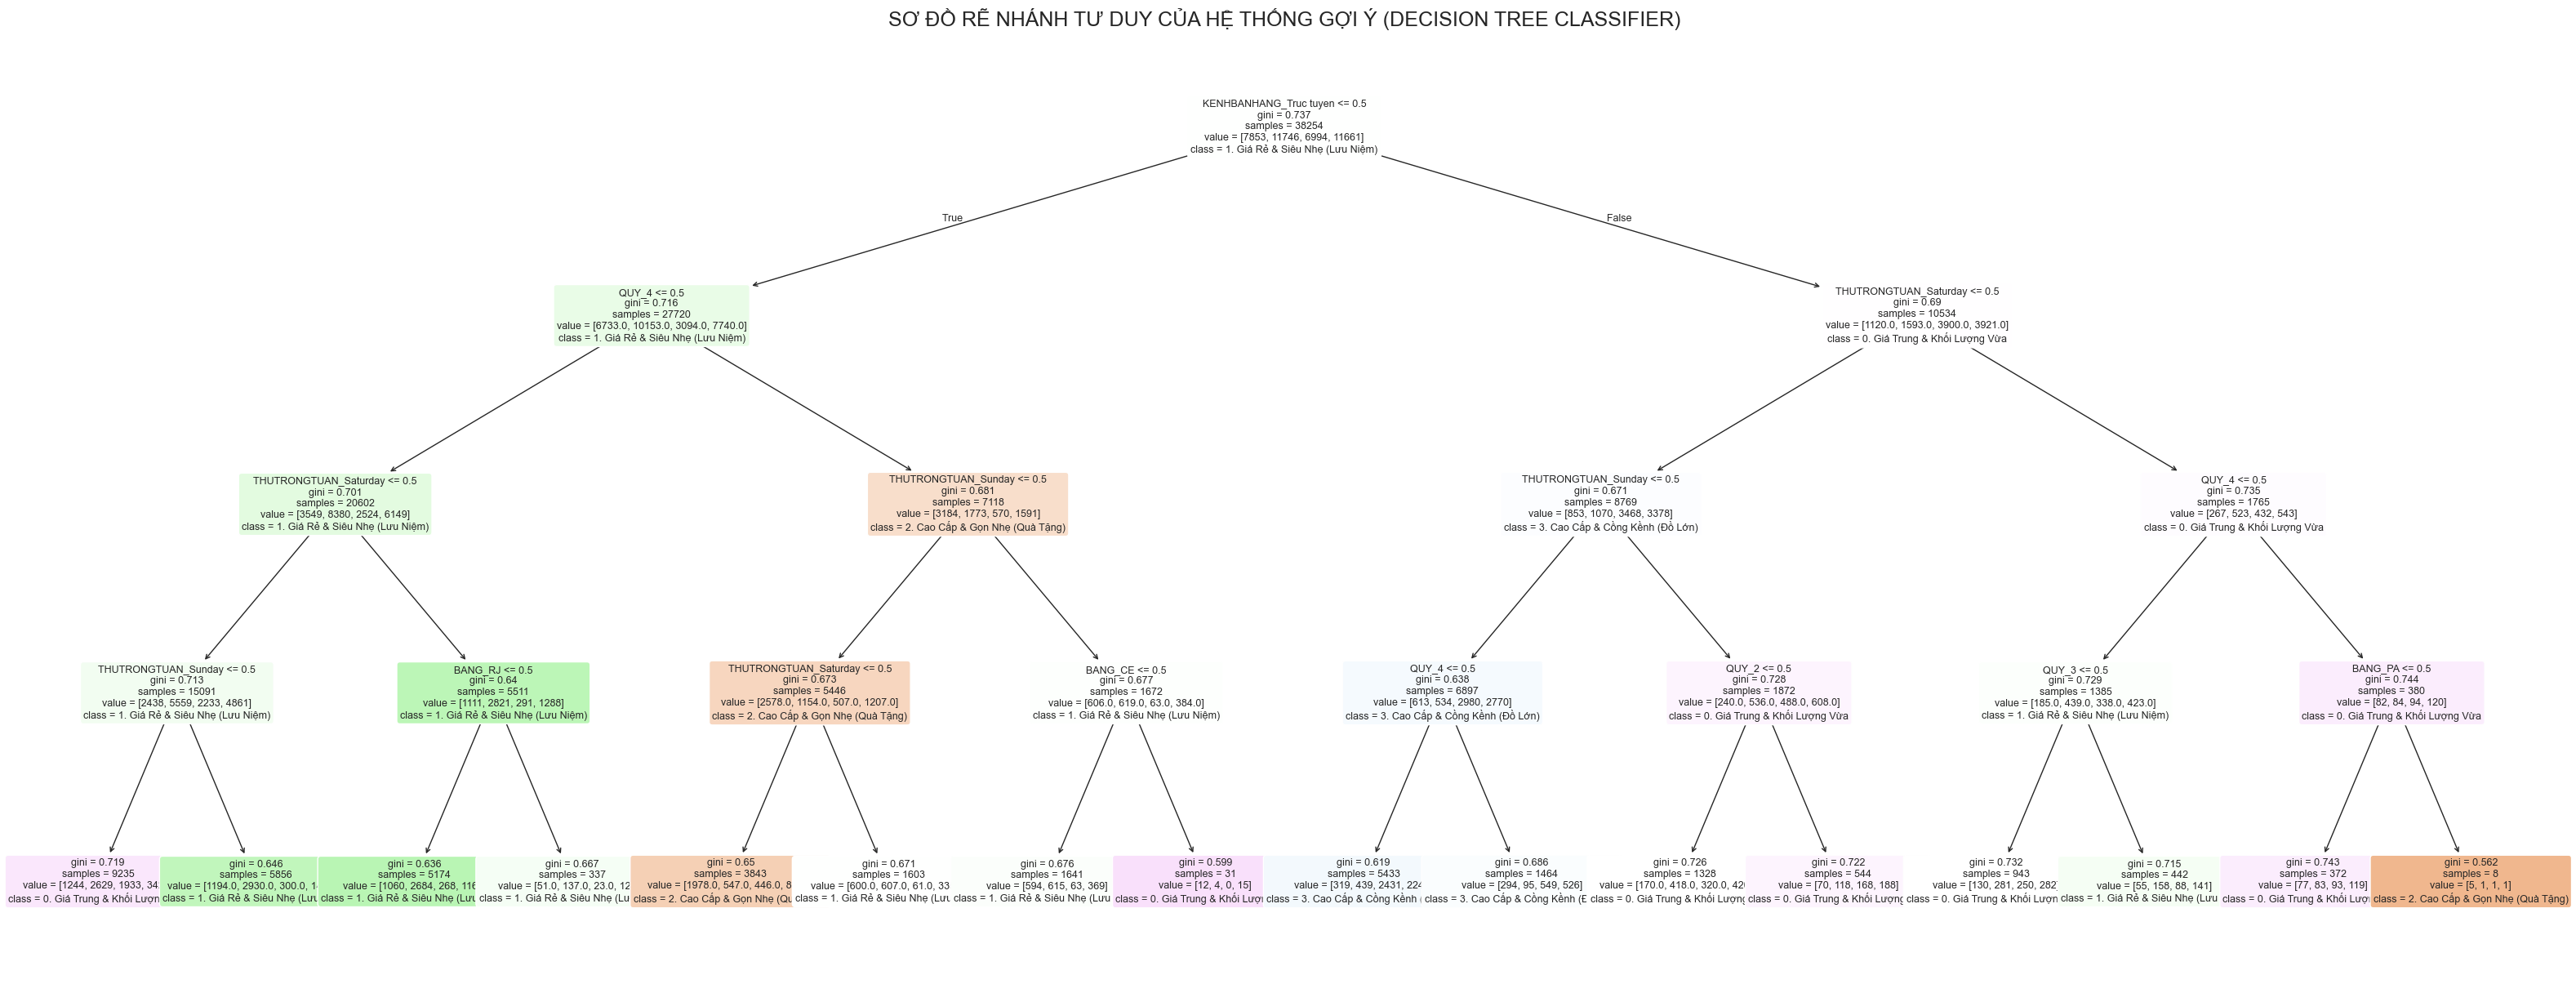

In [8]:
plt.figure(figsize=(40, 15))
plot_tree(clf, 
          feature_names=X_encoded.columns, 
          class_names=[label_map[0], label_map[1], label_map[2], label_map[3]], 
          filled=True, 
          rounded=True, 
          fontsize=9,
          proportion=False)
plt.title("SƠ ĐỒ RẼ NHÁNH TƯ DUY CỦA HỆ THỐNG GỢI Ý (DECISION TREE CLASSIFIER)", fontsize=18)
plt.show()

## Bước 5: Thử nghiệm Thực chiên Dành cho Ban Giám Đốc (Phân luồng Omni-channel)
Bây giờ, Giám đốc hoặc Quản lý chi nhánh không cần chạy nguyên hệ thống web rườm rà. Họ chỉ sửa các thông số Ngữ cảnh thực tế của ngày hôm nay vào đoạn Code giả lập dưới đây, Cỗ máy sẽ tự dự đoán Khách Vãng Lai sẽ mua gì trên kệ.

In [ ]:
def du_doan_hanh_vi_khach_la(bang, quy, thu, kenh):
    # Khởi tạo data khung 0
    input_data = pd.DataFrame(0, index=[0], columns=X_encoded.columns)
    
    # Kích hoạt các Ngữ cảnh bật 1
    if f"BANG_{bang}" in input_data.columns: input_data[f"BANG_{bang}"] = 1
    if f"QUY_{quy}" in input_data.columns: input_data[f"QUY_{quy}"] = 1
    if f"THUTRONGTUAN_{thu}" in input_data.columns: input_data[f"THUTRONGTUAN_{thu}"] = 1
    if f"KENHBANHANG_{kenh}" in input_data.columns: input_data[f"KENHBANHANG_{kenh}"] = 1
        
    # Cho Cây dự đoán
    prediction = clf.predict(input_data)[0]
    print(f"[NGỮ CẢNH ĐA KÊNH] Khách du lịch đến từ {bang}, vào {thu} (Quý {quy}) | Kênh: {kenh}")
    print(f"👉 AI DỰ ĐOÁN CHỐT ĐƠN: {label_map[prediction]}")
    print("-" * 50)

# Kịch bản 1: Màn hình điện tử tại Cửa hàng (Offline) ngày Giáng sinh siêu lạnh
du_doan_hanh_vi_khach_la(bang='MG', quy=4, thu='Saturday', kenh='Tai cua hang')

# Kịch bản 2: Khách ngoại ô lên trang web (Online) vào thứ 2 làm việc
du_doan_hanh_vi_khach_la(bang='CE', quy=2, thu='Monday', kenh='Truc tuyen')

# Kịch bản 3: Dân Thủ đô SP lượn Siêu thị cuối tuần
du_doan_hanh_vi_khach_la(bang='SP', quy=1, thu='Sunday', kenh='Tai cua hang')
